In [1]:
import io
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def load_url(url: str) -> np.ndarray:
    with urllib.request.urlopen(url) as r:
        return np.array(Image.open(io.BytesIO(r.read())).convert("L"))


def preprocess(gray: np.ndarray) -> np.ndarray:
    """Otsu binarization → white foreground on black background."""
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(binary > 0) > 0.5:          # white background → invert
        binary = cv2.bitwise_not(binary)
    kernel = np.ones((3, 3), np.uint8)
    return cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)


def hu_log(binary: np.ndarray) -> np.ndarray:
    h = cv2.HuMoments(cv2.moments(binary)).flatten()
    return -np.sign(h) * np.log10(np.abs(h) + 1e-12)


def largest_contour(binary: np.ndarray):
    cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        raise ValueError("No contour found.")
    return max(cnts, key=cv2.contourArea)


def compare(img1: np.ndarray, img2: np.ndarray, threshold: float = 0.20):
    """
    Hu-moment shape similarity via cv2.matchShapes (I1 method).
    Returns: similar (bool), score (float), b1, b2, hu1, hu2
    Lower score → more similar.
    """
    b1, b2 = preprocess(img1), preprocess(img2)
    score = float(cv2.matchShapes(largest_contour(b1), largest_contour(b2),
                                  cv2.CONTOURS_MATCH_I1, 0.0))
    return score < threshold, score, b1, b2, hu_log(b1), hu_log(b2)


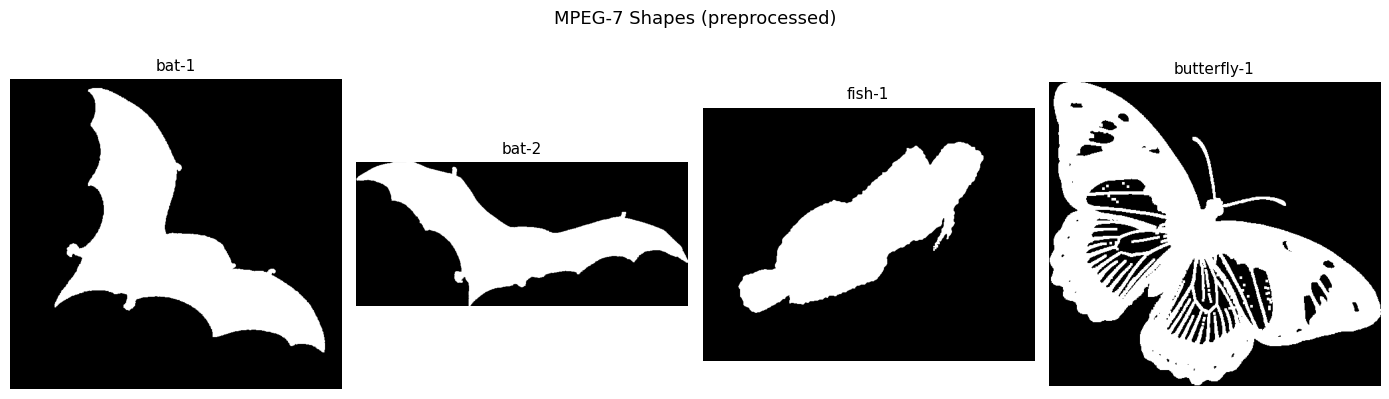

In [2]:
BASE = "https://dabi.temple.edu/external/shape/MPEG7/original"

SHAPES = {
    "bat-1":       f"{BASE}/bat-1.gif",
    "bat-2":       f"{BASE}/bat-2.gif",
    "fish-1":      f"{BASE}/fish-1.gif",
    "butterfly-1": f"{BASE}/butterfly-1.gif",
}

imgs = {name: load_url(url) for name, url in SHAPES.items()}

fig, axes = plt.subplots(1, len(imgs), figsize=(14, 4))
for ax, (name, img) in zip(axes, imgs.items()):
    ax.imshow(preprocess(img), cmap="gray")
    ax.set_title(name, fontsize=11)
    ax.axis("off")
plt.suptitle("MPEG-7 Shapes (preprocessed)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


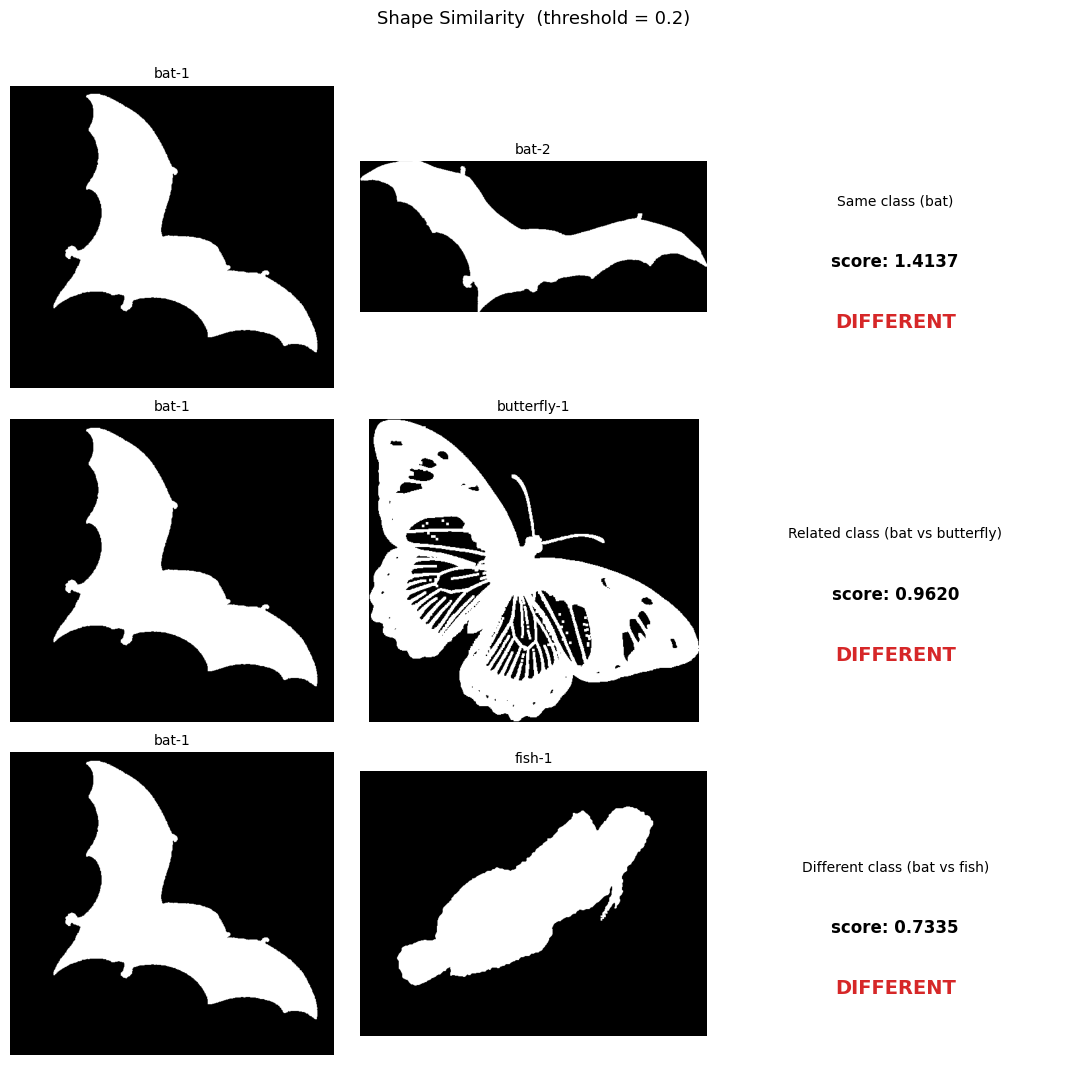

In [3]:
pairs = [
    ("bat-1", "bat-2",       "Same class (bat)"),
    ("bat-1", "butterfly-1", "Related class (bat vs butterfly)"),
    ("bat-1", "fish-1",      "Different class (bat vs fish)"),
]

THRESHOLD = 0.20
fig, axes = plt.subplots(len(pairs), 3, figsize=(11, 3.5 * len(pairs)))

for row, (name_a, name_b, desc) in enumerate(pairs):
    sim, score, b1, b2, _, _ = compare(imgs[name_a], imgs[name_b], threshold=THRESHOLD)
    verdict = "SIMILAR" if sim else "DIFFERENT"
    color   = "#2ca02c" if sim else "#d62728"

    axes[row, 0].imshow(b1, cmap="gray"); axes[row, 0].set_title(name_a, fontsize=10); axes[row, 0].axis("off")
    axes[row, 1].imshow(b2, cmap="gray"); axes[row, 1].set_title(name_b, fontsize=10); axes[row, 1].axis("off")
    axes[row, 2].axis("off")
    axes[row, 2].text(0.5, 0.62, f"{desc}", ha="center", va="center",
                      fontsize=10, transform=axes[row, 2].transAxes)
    axes[row, 2].text(0.5, 0.42, f"score: {score:.4f}", ha="center", va="center",
                      fontsize=12, fontweight="bold", transform=axes[row, 2].transAxes)
    axes[row, 2].text(0.5, 0.22, verdict, ha="center", va="center",
                      fontsize=14, fontweight="bold", color=color,
                      transform=axes[row, 2].transAxes)

plt.suptitle(f"Shape Similarity  (threshold = {THRESHOLD})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


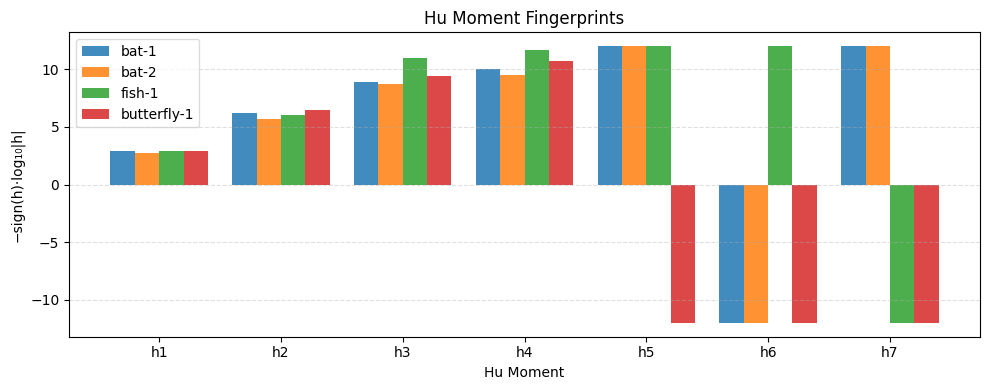

In [4]:
hu_all   = {name: hu_log(preprocess(img)) for name, img in imgs.items()}
x        = np.arange(7)
width    = 0.2
colors   = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, hu) in enumerate(hu_all.items()):
    ax.bar(x + i * width, hu, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"h{i+1}" for i in range(7)])
ax.set_xlabel("Hu Moment")
ax.set_ylabel("−sign(h)·log₁₀|h|")
ax.set_title("Hu Moment Fingerprints")
ax.legend(framealpha=0.7)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
